In [1]:
# Load libraries
import pandas as pd
from mbiomekit.group_comparison import analysis, plotter

In [2]:
# Load data
ft = pd.read_csv('data/ft_genus_prv01.tsv', sep='\t', header=0, index_col=0)
group = pd.read_csv('data/group.tsv', sep='\t', header=0, index_col=0)

In [3]:
# grouping map
grp_map = {}
for sid, g in group['group1'].items():
    grp_map[sid] = g

In [4]:
# Statistical analysis
an = analysis.Analyzer()
an.set_feature_table(ft)
an.set_group(group.loc[:, 'group1'])
an.group_analysis()
an.save_results('data/3-results/group_comparison/kruskal_genus.tsv', 'data/3-results/group_comparison/dunn_genus.json')

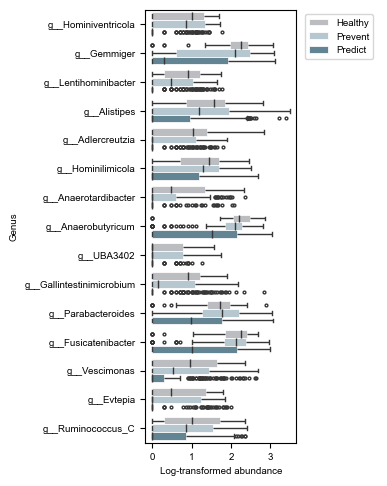

In [5]:
# Plotting
palette = {'Healthy': '#aaadb2',
           'Prevent': '#9fbcca',
           'Predict': '#326a81'}

id_sel = an.result_kruskal.index[an.result_kruskal['adjusted-p'] < 0.05][:15]
ft_sel = ft.loc[id_sel, :]

pt = plotter.Plotter()
pt.plot_microbe_abundance(ft_sel, fout='figures/group_comparison/top15_da_genus.pdf', palette=palette, group_map=grp_map, label='Genus', hue_order=['Healthy', 'Prevent', 'Predict'])